In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("e_ticaret_veriseti_duzenlenmis.csv")

In [3]:
df.columns

Index(['siparis_id', 'musteri_id', 'siparis_tarihi', 'sehir', 'bolge',
       'kategori', 'urun_adi', 'adet', 'birim_fiyat', 'indirim_orani',
       'kargo_ucreti', 'odeme_turu', 'musteri_tipi', 'teslimat_gunu',
       'musteri_puani', 'iade_durumu', 'kar_marji_orani', 'toplam_tutar',
       'siparis_yili', 'siparis_ayi', 'siparis_gunu', 'haftanin_gunu'],
      dtype='object')

In [4]:
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,istanbul,Marmara,kozmetik,Nemlendirici,1,414.51,0.05,...,yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,5
1,SIP100837,MUS1347,2025-03-17 21:13:00,gaziantep,Güneydoğu Anadolu,spor,Dambıl Seti,2,1475.15,0.10,...,vip,4.0,1.0,Hayır,0.361,2685.17,2025,3,17,0
2,SIP100050,MUS1066,2025-06-03 12:42:00,kayseri,İç Anadolu,kitap,İş Analitiği Rehberi,1,289.02,0.05,...,mevcut,6.0,2.0,Hayır,0.348,304.47,2025,6,3,1
3,SIP100263,MUS1008,2024-08-10 15:13:00,antalya,Akdeniz,kitap,Girişimcilik,5,194.78,0.00,...,yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,5
4,SIP100707,MUS1291,2024-08-19 08:24:00,gaziantep,Güneydoğu Anadolu,elektronik,Powerbank,3,841.80,0.05,...,mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,0


##### 1. Hangi kategori hem ticari performans hem de müşteri memnuniyeti açısından en güçlü görünüyor?

* Kategori bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı, ortalama müşteri puanı ve ortalama teslimat günü metriklerini çıkarın.

* Kategori bazlı özet tablo oluşturun.

In [5]:
df_kategori = df.groupby("kategori").agg(
    siparis_sayisi = ("siparis_id", "nunique"),
    toplam_gelir = ("toplam_tutar", "sum"),
    ortalama_siparis_tutari = ("toplam_tutar", "mean"),
    ortalama_musteri_puani = ("musteri_puani", "mean"),
    ortalama_teslimat_gunu = ("teslimat_gunu", "mean")
).reset_index()

In [6]:
df_kategori.head()

,kategori,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
0,elektronik,241,765989.55,3178.379876,4.058091,3.298755
1,ev ve yaşam,216,187901.01,869.912083,3.902778,3.478469
2,kitap,253,145588.25,575.447628,3.980237,3.476000
3,kozmetik,223,203726.63,913.572332,4.143498,3.336406
4,ofis,230,291376.57,1266.854652,3.908696,3.418919


* Toplam gelir için bir bar plot çizdirin.

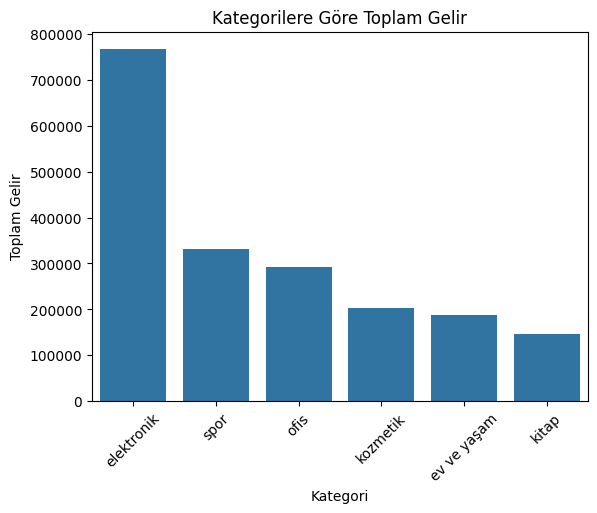

In [7]:
sns.barplot(data= df_kategori.sort_values("toplam_gelir", ascending= False), x= "kategori", y= "toplam_gelir")
plt.title("Kategorilere Göre Toplam Gelir")
plt.xlabel("Kategori")
plt.ylabel("Toplam Gelir")
plt.xticks(rotation= 45)
plt.show()

* Ortalama müşteri puanı için ikinci bir bar plot çizdirin.

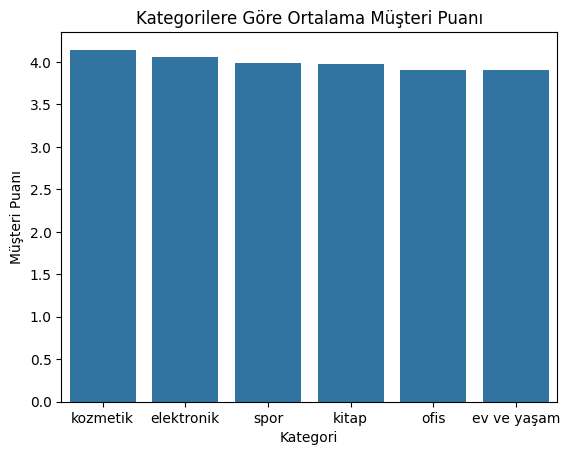

In [8]:
sns.barplot(data= df_kategori.sort_values("ortalama_musteri_puani", ascending= False), x= "kategori", y= "ortalama_musteri_puani")
plt.title("Kategorilere Göre Ortalama Müşteri Puanı")
plt.xlabel("Kategori")
plt.ylabel("Müşteri Puanı")
plt.show()

* Hem gelir hem memnuniyet açısından en güçlü kategoriyi belirleyin ve kısa bir iş yorumu yazın.

##### Kategori bazında gelir incelendiğinde elektronik kategorisinin açık ara birinci; kategori bazında müşteri puanı incelendiğinde ise kozmetik kategorisinin birinci, elektronik kategorisinin ikinci olduğu görülmektedir. İşletme için hem önemli bir gelir kaynağı hem de müşteriler tarafından yüksek memnuniyetle karşılanan elektronik kategorisi hem gelir hem de memnuniyet açısından en güçlü kategori olarak değerlendirilebilir. Bu nedenle elektronik kategorisindeki başarılı performans korunmalıdır.

##### 2. Hangi şehirler daha yüksek potansiyel taşıyor?

* Şehir bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı ve ortalama müşteri puanı metriklerini çıkarın.

* Şehir bazlı özet tablo oluşturun.

In [9]:
df_sehir = df.groupby("sehir").agg(
    siparis_sayisi = ("siparis_id", "nunique"),
    toplam_gelir = ("toplam_tutar", "sum"),
    ortalama_siparis_tutari = ("toplam_tutar", "mean"),
    ortalama_musteri_puani = ("musteri_puani", "mean")
).reset_index()

In [10]:
df_sehir.head()

,sehir,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
0,adana,77,90268.49,1172.318052,4.129870
1,ankara,169,272952.97,1615.106331,3.828402
2,antalya,108,129851.32,1202.327037,4.027778
3,bursa,86,98335.67,1143.438023,3.988372
4,eskişehir,57,86571.89,1518.805088,3.877193


* Toplam gelire göre şehirleri büyükten küçüğe sıralayın.

In [11]:
df_sehir.sort_values("toplam_gelir", ascending= False).head()

,sehir,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
6,istanbul,302,425119.62,1407.680861,4.115894
1,ankara,169,272952.97,1615.106331,3.828402
7,izmir,154,184523.39,1198.203831,3.889610
2,antalya,108,129851.32,1202.327037,4.027778
11,mersin,57,113273.31,1987.251053,4.105263


* En güçlü 5 şehir için bir bar plot çizdirin.

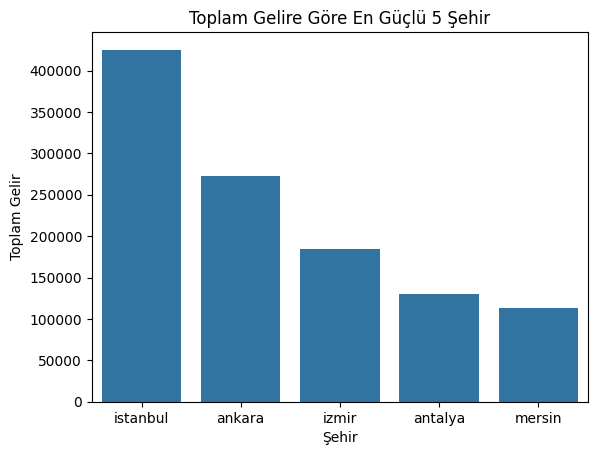

In [12]:
sns.barplot(data= df_sehir.sort_values("toplam_gelir", ascending= False)[:5], x= "sehir", y= "toplam_gelir")
plt.title("Toplam Gelire Göre En Güçlü 5 Şehir")
plt.xlabel("Şehir")
plt.ylabel("Toplam Gelir")
plt.show()

* Müşteri puanı yüksek ama gelir açısından geride kalan şehirleri ayrıca tespit edin ve büyüme adayı şehirler için kısa bir yorum yazın.

In [13]:
df_sehir[["sehir", "ortalama_musteri_puani", "toplam_gelir"]].sort_values(["ortalama_musteri_puani", "toplam_gelir"], ascending= [False, True])

,sehir,ortalama_musteri_puani,toplam_gelir
10,konya,4.218391,101798.84
12,samsun,4.157895,73402.30
0,adana,4.129870,90268.49
6,istanbul,4.115894,425119.62
11,mersin,4.105263,113273.31
5,gaziantep,4.030303,107211.78
2,antalya,4.027778,129851.32
3,bursa,3.988372,98335.67
8,kayseri,3.907407,111551.65
7,izmir,3.889610,184523.39


##### Konya, Samsun ve Adana gibi şehirlerin yüksek müşteri memnuniyetine rağmen gelir açısından geride kaldığı görülmektedir. Bu nedenle bu şehirlerde sepet tutarını artırmaya yönelik kampanyalar düzenlenebilir.

##### 3. Hangi ödeme türü daha değerli müşteri davranışı üretiyor?

* Ödeme türü bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı, ortalama müşteri puanı ve ortalama teslimat günü metriklerini çıkarın.

* Ödeme türüne göre özet tablo oluşturun.

In [14]:
df_odeme_turu = df.groupby("odeme_turu").agg(
    siparis_sayisi = ("siparis_id", "nunique"),
    toplam_gelir = ("toplam_tutar", "sum"),
    ortalama_siparis_tutari = ("toplam_tutar", "mean"),
    ortalama_musteri_puani = ("musteri_puani", "mean"),
    ortalama_teslimat_gunu = ("teslimat_gunu", "mean")
).reset_index()

In [15]:
df_odeme_turu.head()

,odeme_turu,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
0,Banka Kartı,211,287577.59,1362.926967,3.824645,3.485577
1,Dijital Cüzdan,192,317562.26,1653.970104,4.052083,3.276596
2,Havale,4,3856.73,964.182500,4.000000,2.750000
3,Havale/EFT,141,216729.94,1537.091773,3.921986,3.178571
4,Kapida Odeme,5,2665.92,533.184000,4.000000,3.400000


* Ortalama sipariş tutarı için bir bar plot çizdirin.

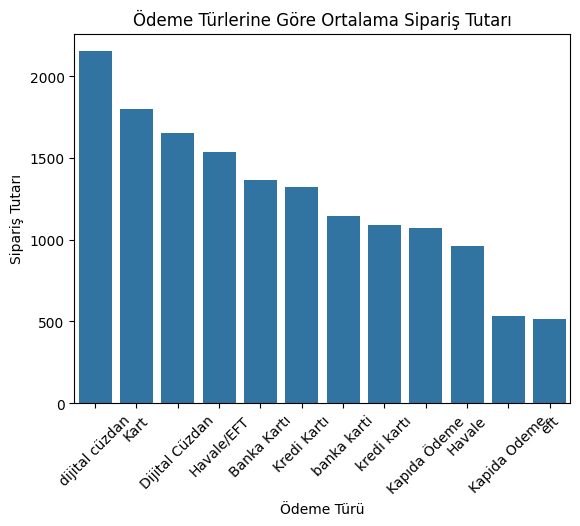

In [16]:
sns.barplot(data= df_odeme_turu.sort_values("ortalama_siparis_tutari", ascending= False), x= "odeme_turu", y= "ortalama_siparis_tutari")
plt.title("Ödeme Türlerine Göre Ortalama Sipariş Tutarı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Sipariş Tutarı")
plt.xticks(rotation= 45)
plt.show()

* Ortalama müşteri puanı için ikinci bir bar plot çizdirin.

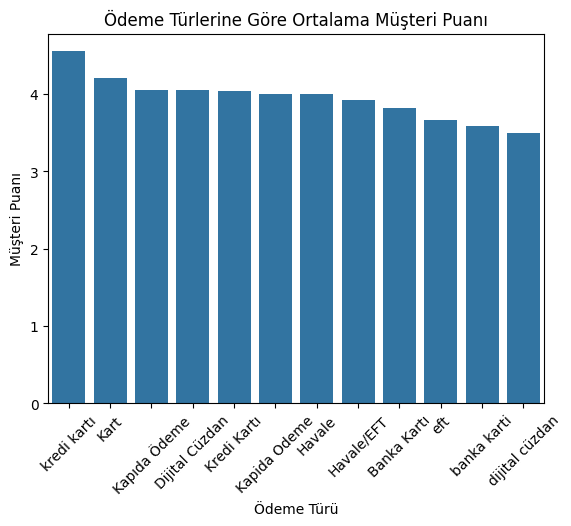

In [17]:
sns.barplot(data= df_odeme_turu.sort_values("ortalama_musteri_puani", ascending= False), x= "odeme_turu", y= "ortalama_musteri_puani")
plt.title("Ödeme Türlerine Göre Ortalama Müşteri Puanı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Müşteri Puanı")
plt.xticks(rotation= 45)
plt.show()

* En yüksek gelir üreten ödeme türü ile en yüksek memnuniyet üreten ödeme türünü karşılaştırın ve sonucu iş diliyle yorumlayın.

##### Ödeme türleri incelendiğinde dijital cüzdanın sipariş tutarında, kredi kartının ise müşteri puanında öne çıktığı görülmektedir. Dijital cüzdan kullanımı teşvik edilerek gelir artırılmaya ve kredi kartındaki memnuniyet korunmaya çalışılmalıdır.

##### 4.  Zaman içinde satış davranışı nasıl değişiyor?

* siparis_tarihi sütununu uygun veri tipine dönüştürün.

* Ay bazında sipariş sayısı, toplam gelir ve ortalama sipariş tutarı metriklerini çıkarın.

In [18]:
df_ay = df.groupby("siparis_ayi").agg(
    siparis_sayisi = ("siparis_id", "nunique"),
    toplam_gelir = ("toplam_tutar", "sum"),
    ortalama_siparis_tutari = ("toplam_tutar", "mean"),
).reset_index()

In [19]:
df_ay.head()

,siparis_ayi,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari
0,1,124,145911.89,1176.708790
1,2,109,149070.92,1367.623119
2,3,123,179130.92,1456.348943
3,4,139,130613.75,939.667266
4,5,125,198230.43,1585.843440


* Sipariş sayısı için bir line plot çizdirin.

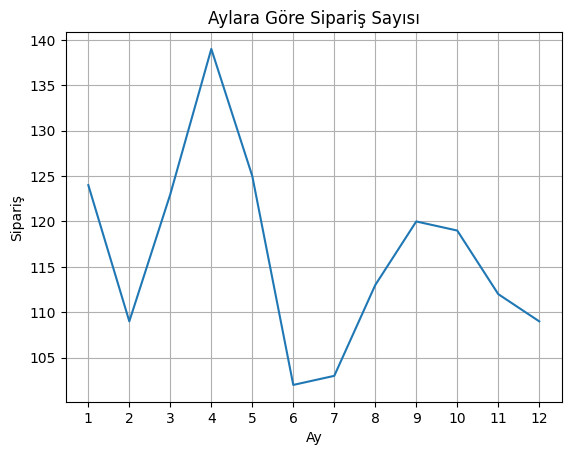

In [20]:
plt.plot(df_ay["siparis_ayi"], df_ay["siparis_sayisi"])
plt.title("Aylara Göre Sipariş Sayısı")
plt.xlabel("Ay")
plt.ylabel("Sipariş")
plt.xticks(df_ay["siparis_ayi"])
plt.grid()
plt.show()

* Toplam gelir için ikinci bir line plot çizdirin.

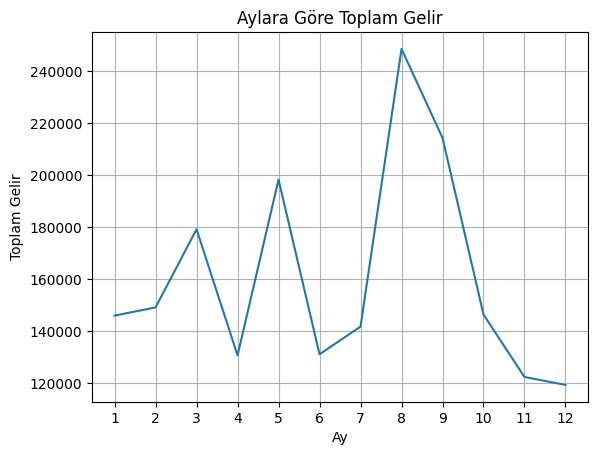

In [21]:
plt.plot(df_ay["siparis_ayi"], df_ay["toplam_gelir"])
plt.title("Aylara Göre Toplam Gelir")
plt.xlabel("Ay")
plt.ylabel("Toplam Gelir")
plt.xticks(df_ay["siparis_ayi"])
plt.grid()
plt.show()

* En yoğun ay ile en yüksek gelir elde edilen ayı karşılaştırın ve “sipariş artışı ile gelir artışı aynı dönemde mi gerçekleşiyor?” sorusuna yorum yapın.

##### Aylara göre sipariş sayısı incelendiğinde en yoğun ayın Nisan, aylara göre toplam gelir incelendiğinde ise en yüksek gelir elde edilen ayın Ağustos olduğu görülmektedir. Bu durum en fazla sipariş verilen ay ile en fazla gelir elde edilen ayın aynı olmadığını göstermektedir. 

##### 5. Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?

* sehir ve kategori kırılımında sipariş sayısı, toplam gelir, ortalama sipariş tutarı ve ortalama müşteri puanı metriklerini çıkarın.

In [22]:
df_sehir_kategori = df.groupby(["sehir", "kategori"]).agg(
    siparis_sayisi = ("siparis_id", "nunique"),
    toplam_gelir = ("toplam_tutar", "sum"),
    ortalama_siparis_tutari = ("toplam_tutar", "mean"),
    ortalama_musteri_puani = ("musteri_puani", "mean"),
).reset_index()

In [23]:
df_sehir_kategori.head()

,sehir,kategori,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
0,adana,elektronik,12,37546.60,3128.883333,4.416667
1,adana,ev ve yaşam,8,8922.99,1115.373750,3.875000
2,adana,kitap,12,5811.48,484.290000,4.000000
3,adana,kozmetik,18,10260.15,570.008333,4.277778
4,adana,ofis,13,5415.80,416.600000,3.769231


* En güçlü 10 şehir-kategori kombinasyonunu bulun.

In [24]:
df_sehir_kategori[["sehir", "kategori", "toplam_gelir"]].sort_values("toplam_gelir", ascending= False).head(10)

,sehir,kategori,toplam_gelir
36,istanbul,elektronik,201081.46
6,ankara,elektronik,107882.67
42,izmir,elektronik,79717.08
41,istanbul,spor,75054.54
10,ankara,ofis,67523.02
48,kayseri,elektronik,58959.61
60,konya,elektronik,55391.63
12,antalya,elektronik,52797.02
40,istanbul,ofis,48977.11
35,gaziantep,spor,44823.00


* Bu kombinasyonları göstermek için uygun bir bar plot oluşturun.

* En güçlü kombinasyonu belirleyin.

In [25]:
df_sehir_kategori["kombinasyon"] = df_sehir_kategori["sehir"] + "-" + df_sehir_kategori["kategori"]

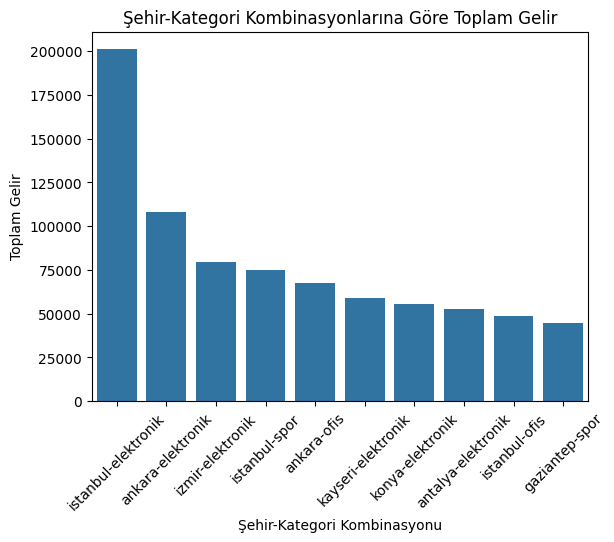

In [26]:
sns.barplot(data= df_sehir_kategori.sort_values("toplam_gelir", ascending= False).head(10), x= "kombinasyon", y= "toplam_gelir")
plt.title("Şehir-Kategori Kombinasyonlarına Göre Toplam Gelir")
plt.xlabel("Şehir-Kategori Kombinasyonu")
plt.ylabel("Toplam Gelir")
plt.xticks(rotation= 45)
plt.show()

* Bu bulgunun pazarlama, kampanya veya ürün stratejisi açısından ne anlama gelebileceğini yorumlayın.

##### Şehir - kategori kombinasyonları incelendiğinde İstanbul - elektronik kombinasyonunun toplam gelir açısından açık ara öne çıktığı görülmektedir. Elektronik kategorisinin farklı şehirlerle birlikte oluşturduğu kombinasyonlarla da ilk 10 içerisinde yer almasından dolayı bu kategori için kampanya yapılabilir ve ürün çeşitlilikleri artırılabilir.